<a href="https://colab.research.google.com/github/doa-2026/machine-learning/blob/main/classification_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load and check Data

In [4]:
path="/content/drive/MyDrive/نسخة من stroke.csv"
import pandas as pd
df=pd.read_csv(path)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Check if the Target is  balanced or not



In [3]:
df["stroke"].value_counts()
# its abinary classifcation ,,, not balanced

NameError: name 'df' is not defined

Import Pakages

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report , accuracy_score ,confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.preprocessing import StandardScaler,OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier , BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression , LinearRegression
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,52


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


Train - Test  Split

In [9]:
target="stroke"
X=df.drop(columns=target)
y=df[target]
X_train ,X_test,y_train ,y_test =train_test_split(X,y,random_state=42)


Create a column Transformer for preprocessing

In [11]:
num_col=X_train.select_dtypes("number").columns
cat_col=X_train.select_dtypes("object").columns
#columns of number

num_imp=SimpleImputer(strategy="mean")
scale=StandardScaler()
num_pip=make_pipeline(num_imp,scale)
num_tap=("number", num_pip , num_col)

#catagorical
cat_imp=SimpleImputer(strategy="constant",fill_value="missing")
encoder=OneHotEncoder(handle_unknown="ignore",sparse_output=False)
cat_pip=make_pipeline(cat_imp,encoder)
cat_tap=("cat",cat_pip,cat_col)

# Colunmn Transformer
preprocessor=ColumnTransformer([num_tap,cat_tap],verbose_feature_names_out=False)
preprocessor



ColumnTransformer(transformers=[('number',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['id', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                  verbose_feature_names_out=False)

Instantiate and Fit the Model

In [12]:
tree=DecisionTreeClassifier(random_state=42)
#make pipline
pip_tree=make_pipeline(preprocessor,tree)
pip_tree.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['id', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [63]:
y_test_pre=pip_tree.predict(X_test)
y_tain_pre=pip_tree.predict(X_train)
print(classification_report(y_test,y_test_pre))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       251
           1       0.24      0.24      0.24        34

    accuracy                           0.82       285
   macro avg       0.57      0.57      0.57       285
weighted avg       0.82      0.82      0.82       285



In [64]:
#Evalute the Model
r=accuracy_score(y_test,y_test_pre)
r

0.8210526315789474

In [65]:
#create a confusion matrix
cm=confusion_matrix(y_test,y_test_pre)
cm

array([[226,  25],
       [ 26,   8]])

In [66]:
cm_df=pd.DataFrame(cm)
cm_df

,0,1
0,226,25
1,26,8


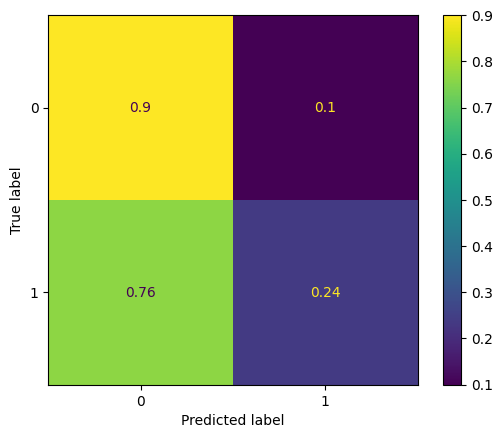

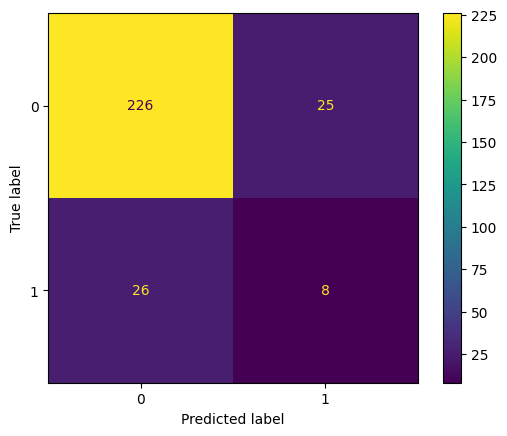

In [67]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pre,normalize="true")
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pre)

1-the accuracy of model  is 0.82 this mean that the model has 80%  is correctly of prediction

2-False postive 0.1


3-False negative 0.76

4-as result above , when 1  as postive class both precsion and recall .24
which is not good ..
recall , because missing stroke patient FN is more dangerous than FP


#Log reg , KNN , random forest  core assigment

##  2) Create a model pipeline that includes a StandardScaler and a default KNeighborsClassifer model (use the default hyperparameters).

In [13]:
knn=KNeighborsClassifier()
pip_knn=make_pipeline(preprocessor,knn)
pip_knn.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['id', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('kneighborsclassifier', KNeighborsClassifier())])

Define Custom Functions

In [14]:
#Evalute the model
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict



def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict



Evaluate this model using a classification report and a Confusion Matrix display.

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       749
           1       0.62      0.17      0.27       103

    accuracy                           0.89       852
   macro avg       0.76      0.58      0.61       852
weighted avg       0.86      0.89      0.86       852



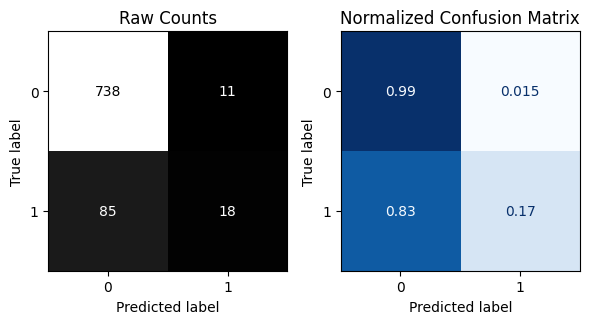


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       251
           1       0.00      0.00      0.00        34

    accuracy                           0.85       285
   macro avg       0.44      0.48      0.46       285
weighted avg       0.77      0.85      0.81       285



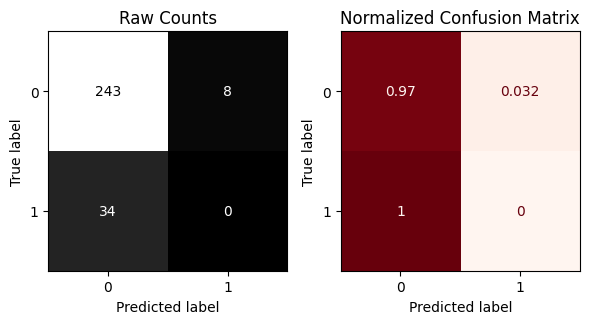

In [15]:
evaluate_classification(pip_knn,X_train,y_train,X_test,y_test)

Tunning hyperparamter (K)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       749
           1       0.57      0.12      0.19       103

    accuracy                           0.88       852
   macro avg       0.73      0.55      0.57       852
weighted avg       0.85      0.88      0.85       852



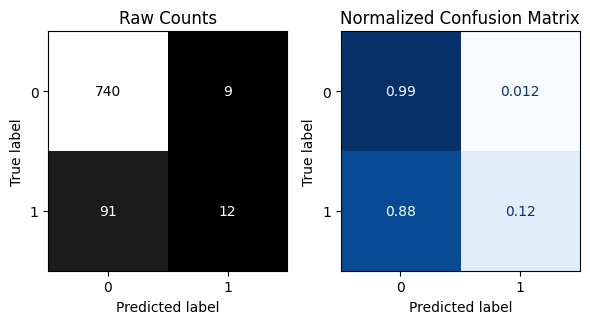


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.17      0.03      0.05        34

    accuracy                           0.87       285
   macro avg       0.52      0.50      0.49       285
weighted avg       0.80      0.87      0.82       285



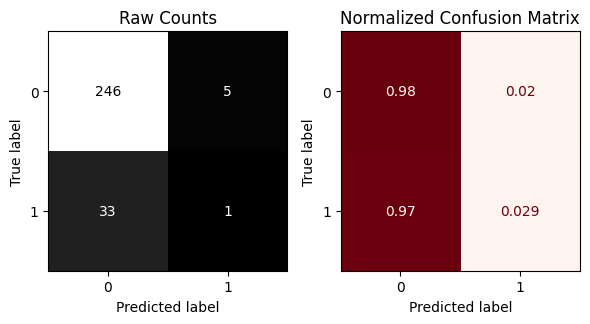

In [16]:
from sklearn.model_selection import GridSearchCV
n_list=list(range(1,20,2))
param = {
    "kneighborsclassifier__n_neighbors": n_list
}

grid = GridSearchCV(pip_knn, param, n_jobs=-1, verbose=1,scoring="recall_macro")
grid.fit(X_train, y_train)

#grid.best_params_
#grid.best_score_
#grid.cv_results_
#r= pd.DataFrame(grid.cv_results_)
grid.best_estimator_
#evaluate tunned- model
evaluate_classification(grid.best_estimator_,X_train,y_train,X_test,y_test)

Which combination of hyperparamter led to the best tunned-model?

 The best parameter when k= 17

**3- Random Forest model

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



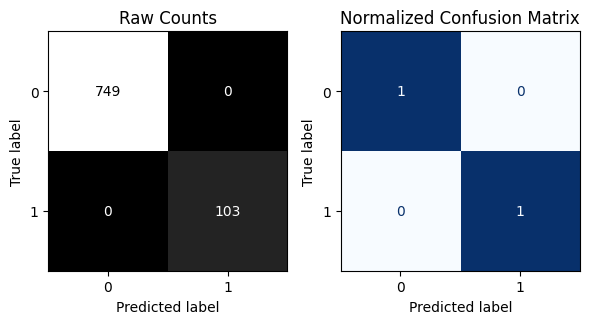


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       251
           1       0.00      0.00      0.00        34

    accuracy                           0.88       285
   macro avg       0.44      0.50      0.47       285
weighted avg       0.78      0.88      0.82       285



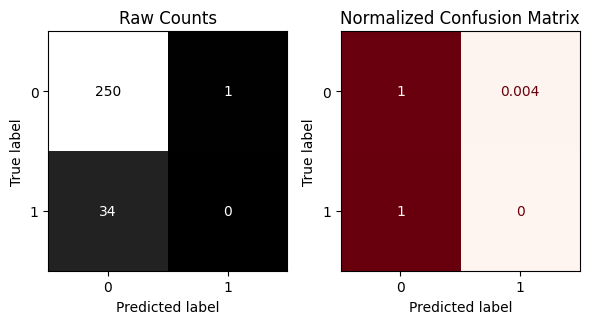

In [17]:
R=RandomForestClassifier(random_state=42)
pip_R=make_pipeline(preprocessor,R)
pip_R.fit(X_train,y_train)

#evaluate the default model
evaluate_classification(pip_R,X_train,y_train,X_test,y_test)


In [18]:
#Tunning hyperparameter
pip_R.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('number',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer()),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['id', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='missing',
                                                                   strategy='constant')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                   

In [19]:
param = {
    "randomforestclassifier__n_estimators": [100,30,50],
    "randomforestclassifier__max_depth": [10,15,20],
    "randomforestclassifier__min_samples_leaf": [1,3],
    "randomforestclassifier__min_samples_split": [2,4]}
g= GridSearchCV(pip_R, param, n_jobs=-1, verbose=1,scoring="recall_macro", cv=3)
g.fit(X_train, y_train)
g.best_params_


Fitting 3 folds for each of 36 candidates, totalling 108 fits


{'randomforestclassifier__max_depth': 20,
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__min_samples_split': 4,
 'randomforestclassifier__n_estimators': 30}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       749
           1       1.00      0.67      0.80       103

    accuracy                           0.96       852
   macro avg       0.98      0.83      0.89       852
weighted avg       0.96      0.96      0.96       852



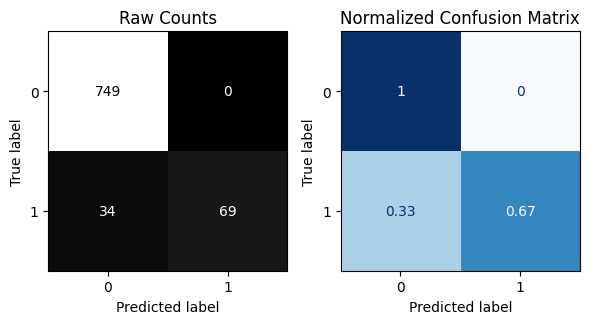


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       251
           1       0.60      0.09      0.15        34

    accuracy                           0.88       285
   macro avg       0.74      0.54      0.55       285
weighted avg       0.85      0.88      0.84       285



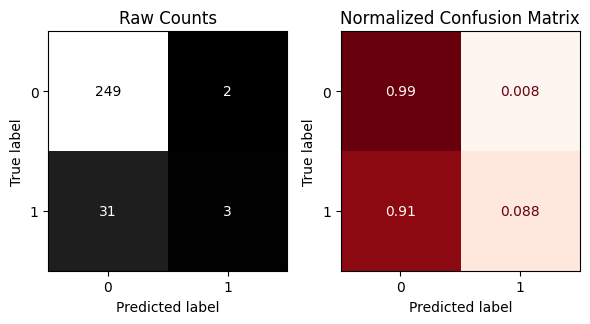

In [20]:
#evaluate the tunned- model
evaluate_classification(g.best_estimator_,X_train,y_train,X_test,y_test)

Which combination of hyperparamter led to the best tunned-model?

The best hyperparameter is

max depth : 20

min sample split :4

min sample leaf: 1

n estimator :30


the precision macro avg is improved from 0.44 to 0.74 , recall macro avg  is small incrasing 0.5 to 0.54

1-Logistic Regression



In [21]:
log=LogisticRegression(random_state=42, max_iter=500)
scale=StandardScaler()
pip_log=make_pipeline(preprocessor,scale,log)
pip_log.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['id', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=500, random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       749
           1       0.54      0.19      0.29       103

    accuracy                           0.88       852
   macro avg       0.72      0.59      0.61       852
weighted avg       0.85      0.88      0.86       852



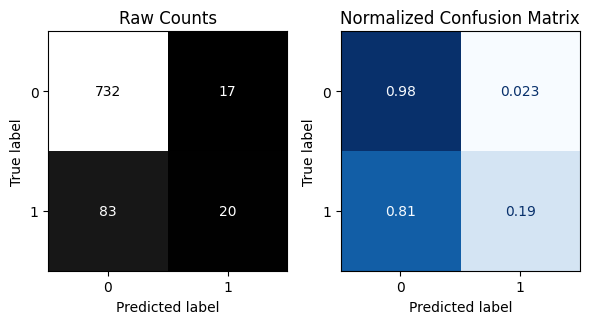


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       251
           1       0.33      0.12      0.17        34

    accuracy                           0.87       285
   macro avg       0.61      0.54      0.55       285
weighted avg       0.82      0.87      0.84       285



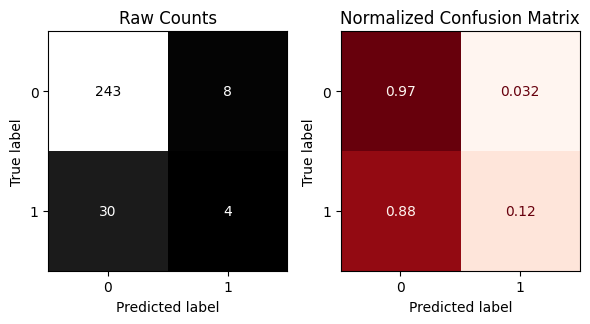

In [22]:
#evaluate the default model
evaluate_classification(pip_log,X_train,y_train,X_test,y_test)

In [59]:
#tunned- model
scale=StandardScaler()
logreg_pip=make_pipeline(preprocessor,LogisticRegression(random_state=42,max_iter=1000))
logreg_pip.get_params()

#define param
param_l1 = {
    "logisticregression__C": [.001,.01,.1,1,10.100,1000]
    ,"logisticregression__l1_ratio": [0,0.25,0.5,0.75,1]
    ,"logisticregression__penalty": ["l1"]
    ,"logisticregression__solver": ["liblinear"]
}

param_l2 = {
    "logisticregression__C": [.001,.01,.1,1,10,100,1000]
    ,"logisticregression__penalty": ["l2"]
    ,"logisticregression__solver": ["lbfgs","liblinear","sag","saga"]
}

param_elasticnet ={
    "logisticregression__l1_ratio": [0,0.25,0.5,0.75,1]
    ,"logisticregression__penalty": ["elasticnet"]
    ,"logisticregression__solver": ["saga"]
}
param = [param_l1,param_l2,param_elasticnet]
gs= GridSearchCV(logreg_pip,param,n_jobs=-1,verbose=1,scoring="recall_macro")
gs.fit(X_train,y_train)
gs.best_params_

Fitting 5 folds for each of 63 candidates, totalling 315 fits


{'logisticregression__C': 100,
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

In [60]:
gs.cv_results_
results=pd.DataFrame(gs.cv_results_)
results


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__l1_ratio,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.088900,0.021378,0.064130,0.015902,0.001,0.00,l1,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,47
1,0.112623,0.037135,0.063074,0.020654,0.001,0.25,l1,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,47
2,0.117455,0.015116,0.065506,0.035688,0.001,0.50,l1,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,47
3,0.131549,0.032178,0.072822,0.011371,0.001,0.75,l1,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,47
4,0.142749,0.013225,0.089244,0.010559,0.001,1.00,l1,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,1.046831,0.122387,0.043676,0.011710,NaN,0.00,elasticnet,saga,"{'logisticregression__l1_ratio': 0, 'logisticr...",0.568095,0.534286,0.536667,0.536667,0.558006,0.546744,0.013719,23
59,0.880246,0.120266,0.024099,0.001636,NaN,0.25,elasticnet,saga,"{'logisticregression__l1_ratio': 0.25, 'logist...",0.568095,0.537619,0.536667,0.536667,0.534196,0.542649,0.012774,33
60,0.928441,0.053073,0.022792,0.001154,NaN,0.50,elasticnet,saga,"{'logisticregression__l1_ratio': 0.5, 'logisti...",0.568095,0.537619,0.536667,0.536667,0.534196,0.542649,0.012774,33
61,1.298161,0.089018,0.021625,0.000254,NaN,0.75,elasticnet,saga,"{'logisticregression__l1_ratio': 0.75, 'logist...",0.568095,0.537619,0.511667,0.536667,0.534196,0.537649,0.017972,35


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       749
           1       0.55      0.20      0.30       103

    accuracy                           0.88       852
   macro avg       0.73      0.59      0.62       852
weighted avg       0.86      0.88      0.86       852



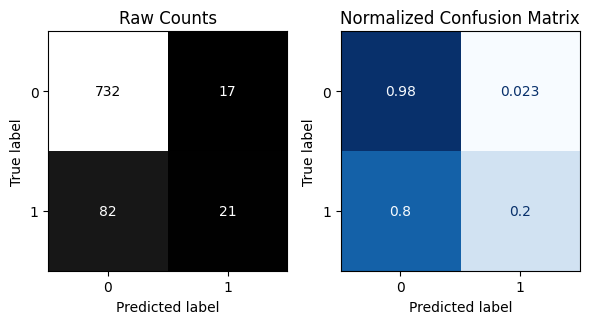


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       251
           1       0.36      0.12      0.18        34

    accuracy                           0.87       285
   macro avg       0.63      0.54      0.55       285
weighted avg       0.83      0.87      0.84       285



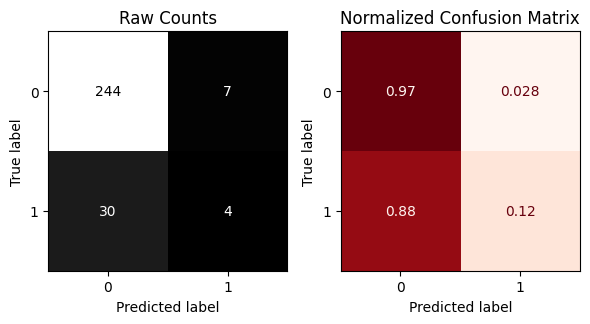

In [61]:
#evalute model
evaluate_classification(gs.best_estimator_,X_train,y_train,X_test,y_test)

Which combination of hyperparamter led to the best tunned-model?

The best hyperparameter:
when using penalty =l2 regularization with solver:liblinear and c=100

we improved the precision  of class 1 from .33 to .36 then macro-avg become .63


Which of your models recommended for production ?

 I choose the tunned -logistic regression model
 and recall metric because missing patient person is more dangrouse than healthy one

 -from my result above the recall improved to .12 and macro avg .59 comparing with other models